# Задача №2.
Освоение наиболее популярных инструментов АВР, и обоснованный выбор методов статистических методов анализа ВР

Импорт библиотек

In [13]:
# Основные импорты для statsforecast
from statsforecast import StatsForecast


from statsforecast.models import (
    # Автоматические модели
    AutoARIMA,
    AutoETS,
    AutoTheta,
    AutoCES,

    # Ручные модели
    ARIMA,
    Theta,

    # Базовые модели (бейзлайны)
    Naive,
    SeasonalNaive,
    RandomWalkWithDrift,
    HistoricAverage,
    WindowAverage,
)

# Стандартные библиотеки
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Основные метрики
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Для RMSE (корень из MSE) можно использовать:
from sklearn.metrics import mean_squared_error
import numpy as np


## 1. Предподготовка датасета для кросс валидации
метод кросс-валидации в statsforecast требует наличия определенным колонок, таких как ds, y, unique_id

In [14]:
import os

if os.getcwd().endswith('notebooks'):
    os.chdir('..')

# Загружаем данные
df = pd.read_csv('data/ETTh1.csv')

# Переименовываем колонки для statsforecast
df = df.rename(columns={
    'date': 'ds',    # колонка с датой → 'ds'
    'OT': 'y'        # целевая переменная → 'y'
})

# Добавляем колонку unique_id (идентификатор временного ряда)
df['unique_id'] = 'ETTh1'

# Преобразуем дату в datetime
df['ds'] = pd.to_datetime(df['ds'])


Анализировать модели мы будем по следующим метрикам:
1. MAE (так как метрика легко интерпретируема и  измеряется в градусах как и целевая переменная)
2. RMSE (эта метрика сильнее штрафует большие ошибки, что критически важно для температуры трансформатора)
3. MASE( используем для сравнения с наивным прогнозом, чтобы понять хороша ли модель в абсолютном значении)

## 2. Тестирование автоматических моделей

In [15]:
# Поскольку прогнозирование по часу требует больших вычислительных ресурсов, будет брать данные раз в день
df_daily = df[['ds', 'y']].copy()
df_daily = df_daily.resample('D', on='ds').mean().reset_index()
df_daily['unique_id'] = 1


# 4 модели (4 автомодели + 1 бейзлайн)
models = [
    AutoARIMA(season_length=7),
    AutoETS(season_length=7),
    AutoTheta(season_length=7),
    SeasonalNaive(season_length=7),
]

# Кросс-валидация (10 недель)
sf = StatsForecast(models=models, freq='D', n_jobs=-1)
cv_results = sf.cross_validation(df=df_daily, h=7, step_size=7, n_windows=10)

baseline_model = 'SeasonalNaive'
baseline_mae = mean_absolute_error(cv_results['y'], cv_results[baseline_model])

# Оценка каждой модели
results_data = []
for model in ['AutoARIMA', 'AutoETS', 'AutoTheta', 'SeasonalNaive']:
    mae = mean_absolute_error(cv_results['y'], cv_results[model])
    rmse = np.sqrt(mean_squared_error(cv_results['y'], cv_results[model]))
    # Процент улучшения относительно бейзлайна
    improvement = ((baseline_mae - mae) / baseline_mae) * 100
    results_data.append({'model': model, 'MAE': mae, 'RMSE': rmse, 'improvement': improvement})

    print(f"{model}: MAE={mae:.3f}°C, RMSE={rmse:.3f}°C, improvement={improvement:.2f}%")

AutoARIMA: MAE=1.657°C, RMSE=2.321°C, improvement=34.71%
AutoETS: MAE=2.361°C, RMSE=3.174°C, improvement=6.96%
AutoTheta: MAE=2.423°C, RMSE=3.222°C, improvement=4.51%
SeasonalNaive: MAE=2.538°C, RMSE=3.357°C, improvement=0.00%


Как мы видим AutoARIMA показывает себя лучше всего.

При этом все модели предсказывают лучше чем SeasonalNaive (Значение = значение неделю назад)

### Построение графиков

C:\Users\PC Acer\AppData\Local\Temp\ipykernel_12668\1771632141.py:77: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax4.boxplot(errors_data, labels=models_list, patch_artist=True, widths=0.6)


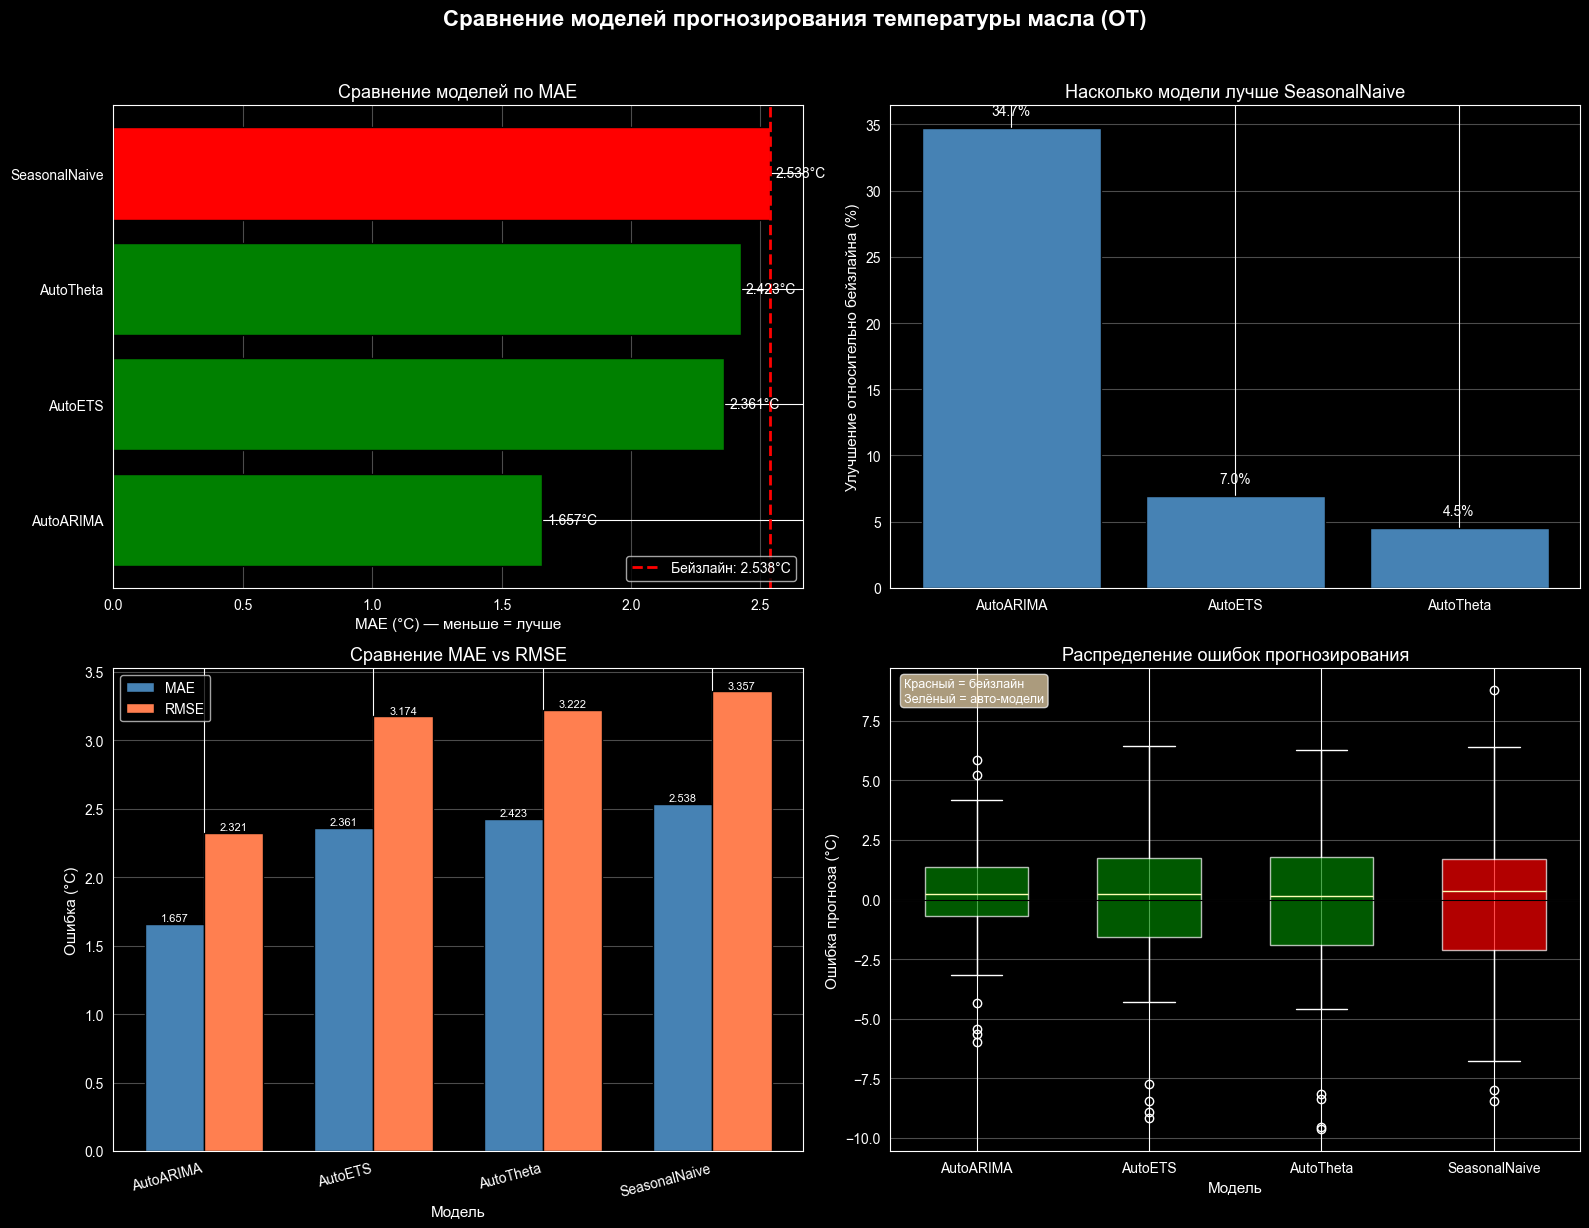

In [16]:

models_list = ['AutoARIMA', 'AutoETS', 'AutoTheta', 'SeasonalNaive']
mae_values = [r['MAE'] for r in results_data]
rmse_values = [r['RMSE'] for r in results_data]
improvements = [r['improvement'] for r in results_data]

# Создаём фигуру с 4 подграфиками
fig = plt.figure(figsize=(16, 12))


# График 1: Сравнение MAE (горизонтальные столбцы)

ax1 = fig.add_subplot(2, 2, 1)
colors = ['green' if m != 'SeasonalNaive' else 'red' for m in models_list]
bars = ax1.barh(models_list, mae_values, color=colors, edgecolor='black')
ax1.axvline(x=baseline_mae, color='red', linestyle='--', linewidth=2,
            label=f'Бейзлайн: {baseline_mae:.3f}°C')
ax1.set_xlabel('MAE (°C) — меньше = лучше', fontsize=11)
ax1.set_title('Сравнение моделей по MAE', fontsize=13)
ax1.legend(loc='lower right')
ax1.grid(True, alpha=0.3, axis='x')

for i, (bar, mae) in enumerate(zip(bars, mae_values)):
    ax1.text(mae + 0.02, bar.get_y() + bar.get_height()/2,
             f'{mae:.3f}°C', va='center', fontsize=10)


# График 2: Процент улучшения относительно бейзлайна

ax2 = fig.add_subplot(2, 2, 2)
models_improved = [m for m in models_list if m != 'SeasonalNaive']
improvements_improved = [improvements[i] for i in range(len(models_list)) if models_list[i] != 'SeasonalNaive']

bars2 = ax2.bar(models_improved, improvements_improved, color='steelblue', edgecolor='black')
ax2.axhline(y=0, color='black', linewidth=0.5)
ax2.set_ylabel('Улучшение относительно бейзлайна (%)', fontsize=11)
ax2.set_title('Насколько модели лучше SeasonalNaive', fontsize=13)
ax2.grid(True, alpha=0.3, axis='y')

for bar, imp in zip(bars2, improvements_improved):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{imp:.1f}%', ha='center', fontsize=10)


# График 3: Сравнение MAE и RMSE

ax3 = fig.add_subplot(2, 2, 3)
x = np.arange(len(models_list))
width = 0.35

bars3_1 = ax3.bar(x - width/2, mae_values, width, label='MAE', color='steelblue', edgecolor='black')
bars3_2 = ax3.bar(x + width/2, rmse_values, width, label='RMSE', color='coral', edgecolor='black')

ax3.set_xlabel('Модель', fontsize=11)
ax3.set_ylabel('Ошибка (°C)', fontsize=11)
ax3.set_title('Сравнение MAE vs RMSE', fontsize=13)
ax3.set_xticks(x)
ax3.set_xticklabels(models_list, rotation=15, ha='right')
ax3.legend()
ax3.grid(True, alpha=0.3, axis='y')

for bar in bars3_1:
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{bar.get_height():.3f}', ha='center', fontsize=8)
for bar in bars3_2:
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{bar.get_height():.3f}', ha='center', fontsize=8)


# График 4: Распределение ошибок (boxplot)

ax4 = fig.add_subplot(2, 2, 4)
errors_data = []
for model in models_list:
    errors = cv_results['y'] - cv_results[model]
    errors_data.append(errors)

bp = ax4.boxplot(errors_data, labels=models_list, patch_artist=True, widths=0.6)

colors_box = ['green', 'green', 'green', 'red']
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax4.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
ax4.set_ylabel('Ошибка прогноза (°C)', fontsize=11)
ax4.set_xlabel('Модель', fontsize=11)
ax4.set_title('Распределение ошибок прогнозирования', fontsize=13)
ax4.grid(True, alpha=0.3, axis='y')

ax4.text(0.02, 0.98, 'Красный = бейзлайн\nЗелёный = авто-модели',
         transform=ax4.transAxes, fontsize=9,
         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))

plt.suptitle('Сравнение моделей прогнозирования температуры масла (OT)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()




AutoARIMA предсказывает временной ряд лучше всего из автоматических моделей, построим график для сравнения реальных значений и предсказанных

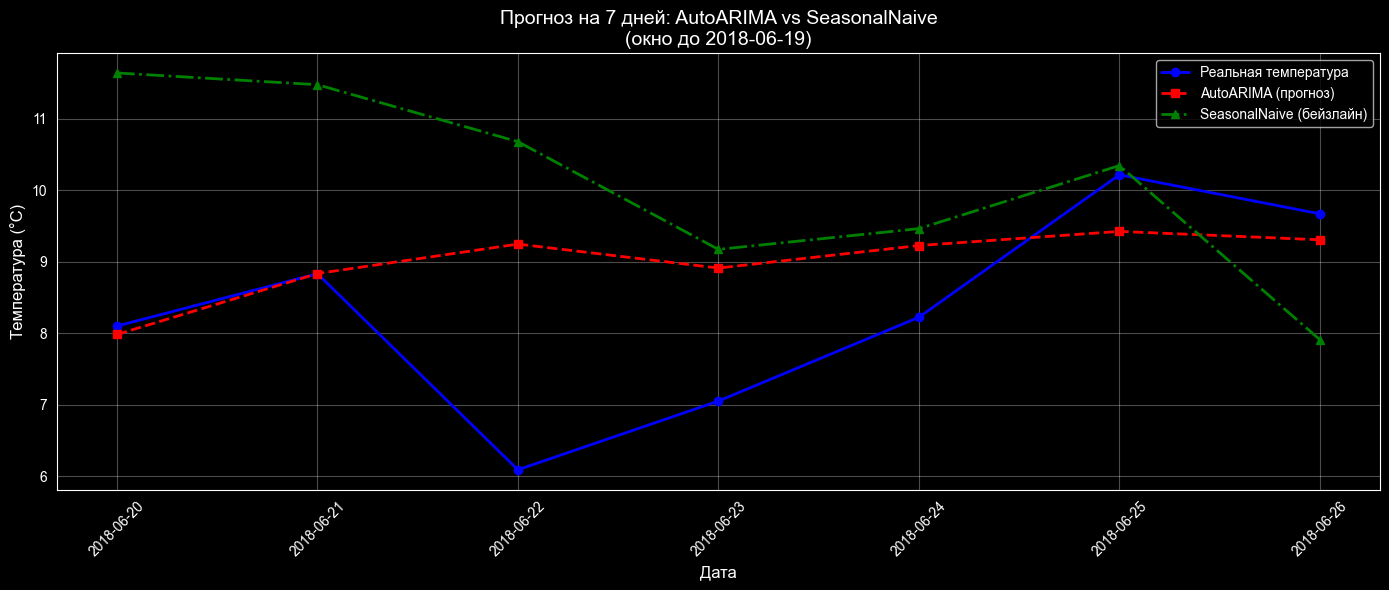

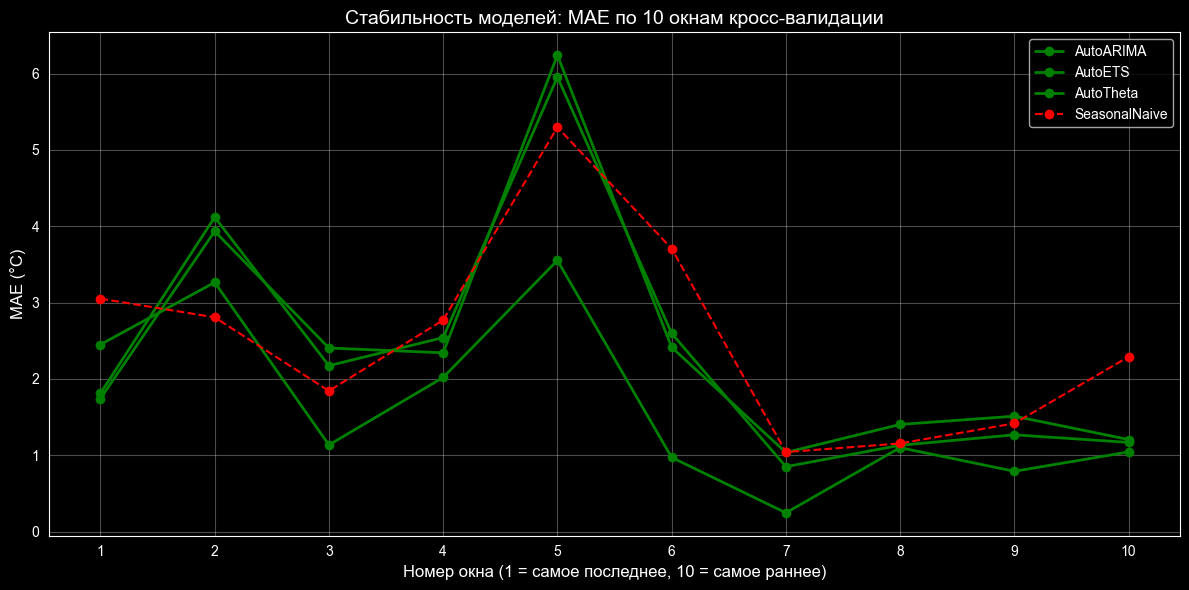

In [17]:
# График:  Прогноз лучшей модели vs Реальность

best_model = models_list[np.argmin(mae_values)]
last_cutoff = cv_results['cutoff'].max()
last_window = cv_results[cv_results['cutoff'] == last_cutoff]

plt.figure(figsize=(14, 6))
plt.plot(last_window['ds'], last_window['y'], 'bo-', label='Реальная температура', linewidth=2, markersize=6)
plt.plot(last_window['ds'], last_window[best_model], 'r--s', label=f'{best_model} (прогноз)', linewidth=2, markersize=6)
plt.plot(last_window['ds'], last_window['SeasonalNaive'], 'g-.^', label='SeasonalNaive (бейзлайн)', linewidth=2, markersize=6)

plt.xlabel('Дата', fontsize=12)
plt.ylabel('Температура (°C)', fontsize=12)
plt.title(f'Прогноз на 7 дней: {best_model} vs SeasonalNaive\n(окно до {last_cutoff.date()})', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)

plt.tight_layout()

plt.show()


# График стабильности: MAE по окнам

plt.figure(figsize=(12, 6))

cutoffs = sorted(cv_results['cutoff'].unique())

for model in models_list:
    window_maes = []
    for cutoff in cutoffs:
        window_data = cv_results[cv_results['cutoff'] == cutoff]
        mae_win = mean_absolute_error(window_data['y'], window_data[model])
        window_maes.append(mae_win)

    line_style = '-' if model != 'SeasonalNaive' else '--'
    line_width = 2 if model != 'SeasonalNaive' else 1.5
    color = 'green' if model != 'SeasonalNaive' else 'red'
    plt.plot(range(1, len(cutoffs)+1), window_maes,
             marker='o', linestyle=line_style, linewidth=line_width,
             label=model, color=color, markersize=6)

plt.xlabel('Номер окна (1 = самое последнее, 10 = самое раннее)', fontsize=12)
plt.ylabel('MAE (°C)', fontsize=12)
plt.title('Стабильность моделей: MAE по 10 окнам кросс-валидации', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(range(1, len(cutoffs)+1))

plt.tight_layout()


## 3. Модель с ручным подбором параметров

По скольку AutoARIMA показала себя лучше всех, попробуем взять ARIMA и с помощью ручной настройки улучшить точность

### 3.1 Определение параметра d (степень дифференцирования)
Параметр d отвечает за стационарность ряда. Стационарный ряд — это ряд, у которого среднее, дисперсия и автокорреляция не меняются во времени.


Cтационарость ряда проверим с помощью теста  Дики-Фуллера (ADF)

In [18]:
from statsmodels.tsa.stattools import adfuller

# ADF тест
result = adfuller(df_daily['y'])
print(f'ADF Statistic: {result[0]:.4f}')
print(f'p-value: {result[1]:.4f}')


ADF Statistic: -2.2534
p-value: 0.1874


p-value больше 0,05 поэтому мы не можем сказать, что ряд стационарен, продифференцируем ряд и посмотрим будет ли он стационарен после этого

In [19]:
# d=1
print("\nПосле первой разности (d=1):")
diff1 = df_daily['y'].diff().dropna()
result = adfuller(diff1)
print(f"  p-value: {result[1]:.4f} → {'стационарный' if result[1] < 0.05 else 'НЕстационарный'}")



После первой разности (d=1):
  p-value: 0.0000 → стационарный


Достаточно один раз продифференцировать модель для стационарности,
#### Вывод: параметр d = 1

### 3.2 Определение параметра p и q

Определять параметры будем с помощью ACF/PACF

ACF (Autocorrelation Function) — корреляция ряда с его лагированными версиями

PACF (Partial Autocorrelation Function) — корреляция с конкретным лагом после исключения влияния промежуточных лагов

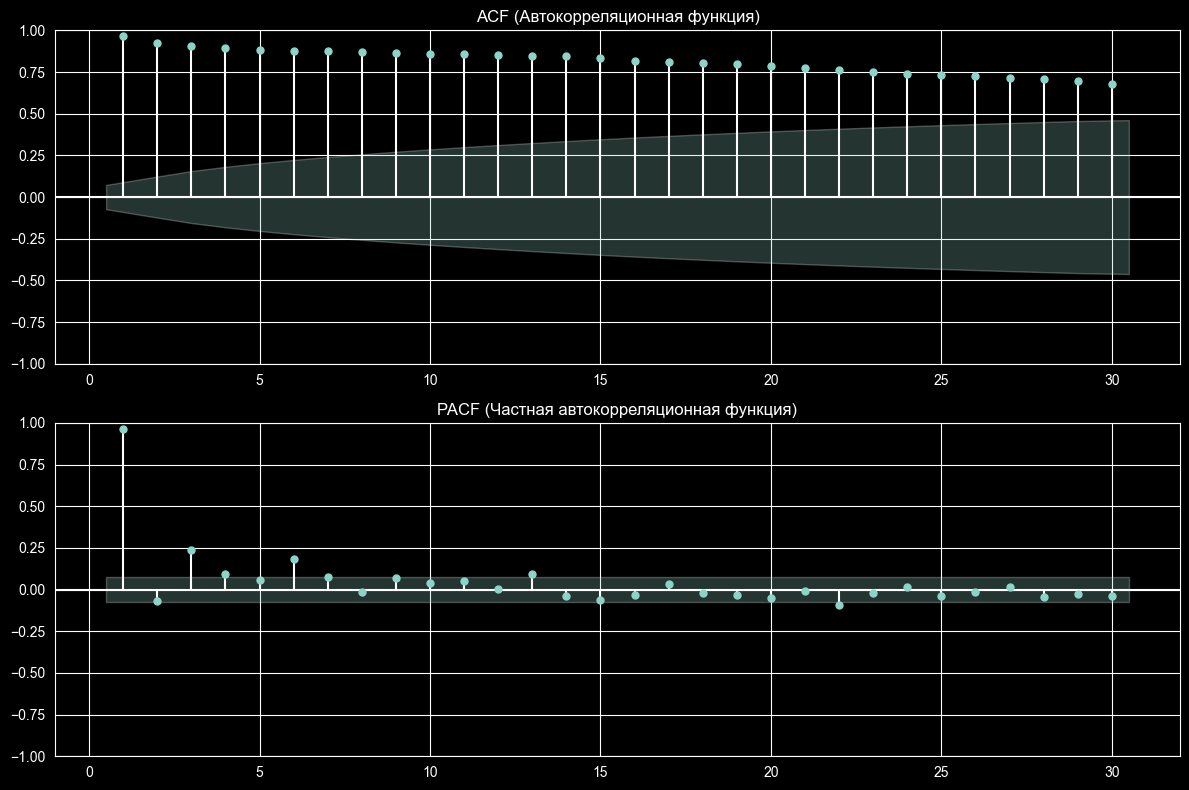

In [20]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

# Берём стационарный ряд (после дифференцирования, если нужно)
series = df_daily['y']  # или diff_series

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# ACF
plot_acf(series, lags=30, zero=False, ax=ax1)
ax1.set_title('ACF (Автокорреляционная функция)')

# PACF
plot_pacf(series, lags=30, zero=False, ax=ax2)
ax2.set_title('PACF (Частная автокорреляционная функция)')

plt.tight_layout()
plt.show()

Мы видим что ACF затухает очень медленно, это означает что сегодняшняя температура сильно зависит от вчерашней и эта зависимость сохраняется многие дни
PACF затухает сразу же после первого лага, это означает что только вчерашний день имеет прямое влияние, позавчерашний влияет только косвенно (через вчерашний)

**Вывод: нам нужны такие параметры модели, чтобы она опиралась на прошлые значения ряда для прогноза и не учитывает прошлые ошибки AR(1) модель с параметрами p = 1, q = 0, d = 1**


In [21]:

# Ручная ARIMA
manual_arima = ARIMA(
    order=(1, 1, 0),
    season_length=365
)

# Кросс-валидация (10 недель)
sf = StatsForecast(models=[manual_arima], freq='D', n_jobs=-1)
cv_results = sf.cross_validation(df=df_daily, h=7, step_size=7, n_windows=10)


mae_ARIMA = mean_absolute_error(cv_results['y'], cv_results['ARIMA'])
rmse_ARIMA = np.sqrt(mean_squared_error(cv_results['y'], cv_results['ARIMA']))
improvement_ARIMA = ((baseline_mae - mae_ARIMA) / baseline_mae) * 100

print(f"ARIMA(1,1,0): MAE={mae_ARIMA:.3f}°C, RMSE={rmse_ARIMA:.3f}°C,improvement={improvement_ARIMA:.3f}%")
# print(f"ARIMA(1,1,0): improvement={improvement_ARIMA:.2f}%")

ARIMA(1,1,0): MAE=2.349°C, RMSE=3.163°C,improvement=7.435%


Результаты сильно хуже чем у автоаримы, попробуем подобрать параметры перебором, попутно сравнивая метрики с автомаримой

In [22]:
# Получаем mae_auto из ранее выполненных расчётов
mae_auto = [r['MAE'] for r in results_data if r['model'] == 'AutoARIMA'][0]
print(f"AutoARIMA MAE = {mae_auto:.4f}°C")

# Сетка параметров для перебора
p_values = [0, 1, 2, 3]
d_values = [0, 1]
q_values = [0, 1, 2]

best_mae = float('inf')
best_params = None
results_manual = []

# Инициализируем переменные значениями по умолчанию
best_rmse = None
best_improvement = None

for p in p_values:
    for d in d_values:
        for q in q_values:
            try:
                # Создаём модель
                model = ARIMA(order=(p, d, q))

                # Кросс-валидация (меньше окон для скорости)
                sf = StatsForecast(models=[model], freq='D', n_jobs=-1)
                cv_results_manual = sf.cross_validation(df=df_daily, h=7, step_size=7, n_windows=5)

                # Оценка
                mae = mean_absolute_error(cv_results_manual['y'], cv_results_manual['ARIMA'])
                rmse_AR = np.sqrt(mean_squared_error(cv_results_manual['y'], cv_results_manual['ARIMA']))  # Исправлено: cv_results_manual
                improvement_AR = ((baseline_mae - mae) / baseline_mae) * 100
                results_manual.append({'order': (p, d, q), 'MAE': mae})

                if mae < best_mae:
                    best_mae = mae
                    best_params = (p, d, q)
                    best_rmse = rmse_AR
                    best_improvement = improvement_AR

            except Exception as e:
                print(f"ARIMA({p},{d},{q}): ошибка - {str(e)[:50]}")

# Проверяем, была ли найдена хотя бы одна модель
if best_params is not None:
    print(f"Лучшая ручная ARIMA{best_params}: MAE = {best_mae:.4f}°C, RMSE = {best_rmse:.4f}, improvement = {best_improvement:.2f}%")
    print(f"AutoARIMA: MAE = {mae_auto:.4f}°C")

    if best_mae < mae_auto:
        print(f"✓ Ручная ARIMA{best_params} ЛУЧШЕ AutoARIMA на {(mae_auto - best_mae):.4f}°C!")
    else:
        print(f" AutoARIMA ЛУЧШЕ ручной на {(best_mae - mae_auto):.4f}°C")
        print(f"   Разница: {(best_mae - mae_auto) / mae_auto * 100:.1f}%")


AutoARIMA MAE = 1.6567°C
Лучшая ручная ARIMA(2, 0, 2): MAE = 0.8722°C, RMSE = 1.1960, improvement = 65.63%
AutoARIMA: MAE = 1.6567°C
✓ Ручная ARIMA(2, 0, 2) ЛУЧШЕ AutoARIMA на 0.7845°C!


С помощью перебора получилось подобрать параметры лучше чем у AutoARIMA и добиться ошибки с прогнозом на недлею менее 1 градуса, построим графики для итогов и лучшей визуализации

## Графики модели с ручным подбором параметров

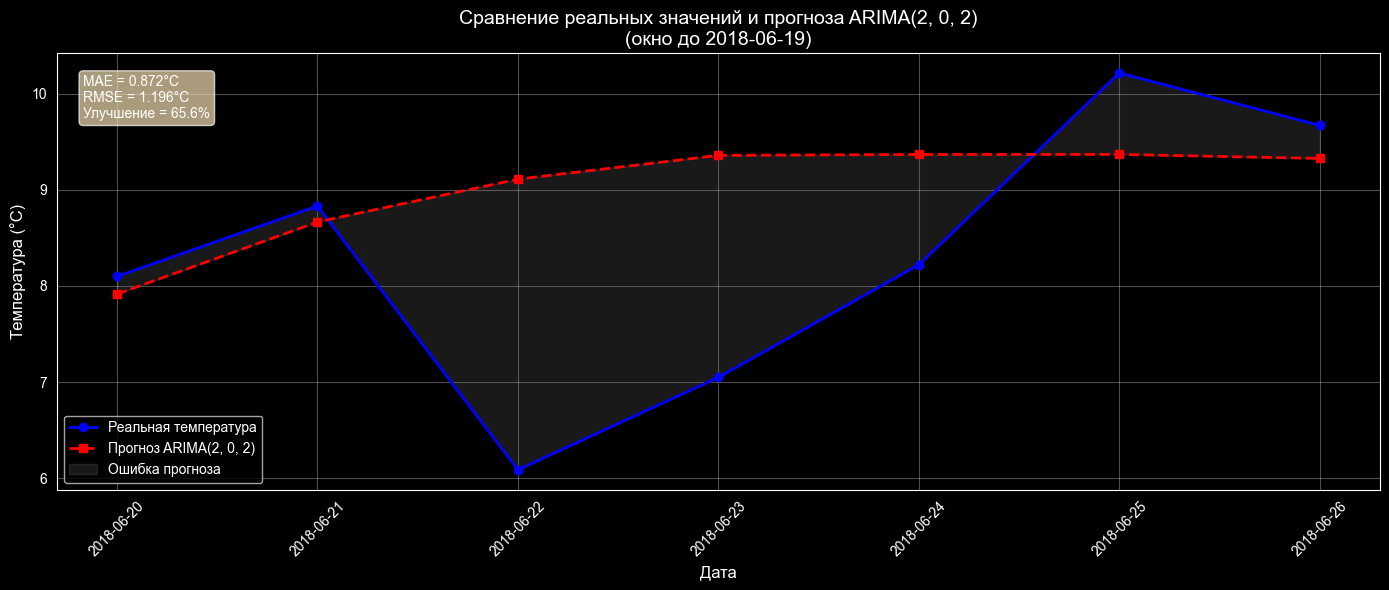


 Лучшая модель: ARIMA(2, 0, 2)
   MAE = 0.8722°C
   RMSE = 1.1960°C
   Улучшение относительно бейзлайна: 65.63%


In [23]:
import matplotlib.pyplot as plt

# Лучшая модель уже обучена в цикле, но cv_results_manual содержит все прогнозы
# Давайте визуализируем сравнение для последнего окна

# Находим последнее окно в результатах кросс-валидации
last_cutoff = cv_results_manual['cutoff'].max()
last_window = cv_results_manual[cv_results_manual['cutoff'] == last_cutoff]

# Создаём график
fig, ax = plt.subplots(figsize=(14, 6))

# Реальные значения
ax.plot(last_window['ds'], last_window['y'],
        'o-', color='blue', linewidth=2, markersize=6, label='Реальная температура')

# Прогноз лучшей ARIMA
ax.plot(last_window['ds'], last_window['ARIMA'],
        's--', color='red', linewidth=2, markersize=6, label=f'Прогноз ARIMA{best_params}')

# Заполняем область ошибки
ax.fill_between(last_window['ds'],
                last_window['y'],
                last_window['ARIMA'],
                alpha=0.2, color='gray', label='Ошибка прогноза')

ax.set_xlabel('Дата', fontsize=12)
ax.set_ylabel('Температура (°C)', fontsize=12)
ax.set_title(f'Сравнение реальных значений и прогноза ARIMA{best_params}\n(окно до {last_cutoff.date()})', fontsize=14)
ax.legend(loc='best')
ax.grid(True, alpha=0.3)
ax.tick_params(axis='x', rotation=45)

# Добавляем метрики на график
ax.text(0.02, 0.95, f'MAE = {best_mae:.3f}°C\nRMSE = {best_rmse:.3f}°C\nУлучшение = {best_improvement:.1f}%',
        transform=ax.transAxes, fontsize=10,
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))

plt.tight_layout()

plt.show()

print(f"\n Лучшая модель: ARIMA{best_params}")
print(f"   MAE = {best_mae:.4f}°C")
print(f"   RMSE = {best_rmse:.4f}°C")
print(f"   Улучшение относительно бейзлайна: {best_improvement:.2f}%")

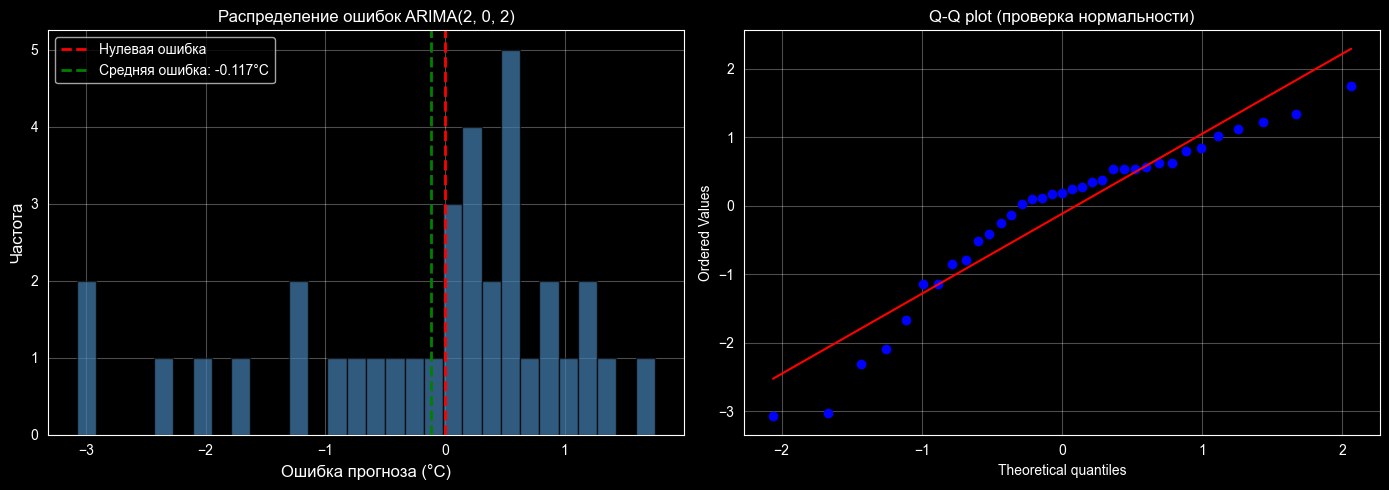


 Тест Шапиро-Уилка (нормальность ошибок):
   p-value = 0.0070
 Ошибки НЕ распределены нормально


In [24]:
# Берём все ошибки из кросс-валидации
errors = cv_results_manual['y'] - cv_results_manual['ARIMA']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Гистограмма ошибок
axes[0].hist(errors, bins=30, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].axvline(x=0, color='red', linestyle='--', linewidth=2, label='Нулевая ошибка')
axes[0].axvline(x=errors.mean(), color='green', linestyle='--', linewidth=2,
                label=f'Средняя ошибка: {errors.mean():.3f}°C')
axes[0].set_xlabel('Ошибка прогноза (°C)', fontsize=12)
axes[0].set_ylabel('Частота', fontsize=12)
axes[0].set_title(f'Распределение ошибок ARIMA{best_params}', fontsize=12)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Q-Q plot
from scipy import stats
stats.probplot(errors, dist="norm", plot=axes[1])
axes[1].set_title('Q-Q plot (проверка нормальности)', fontsize=12)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()

plt.show()

# Тест на нормальность
from scipy.stats import shapiro
shapiro_stat, shapiro_p = shapiro(errors)
print(f"\n Тест Шапиро-Уилка (нормальность ошибок):")
print(f"   p-value = {shapiro_p:.4f}")
if shapiro_p > 0.05:
    print("    Ошибки распределены нормально (хороший признак)")
else:
    print(" Ошибки НЕ распределены нормально")

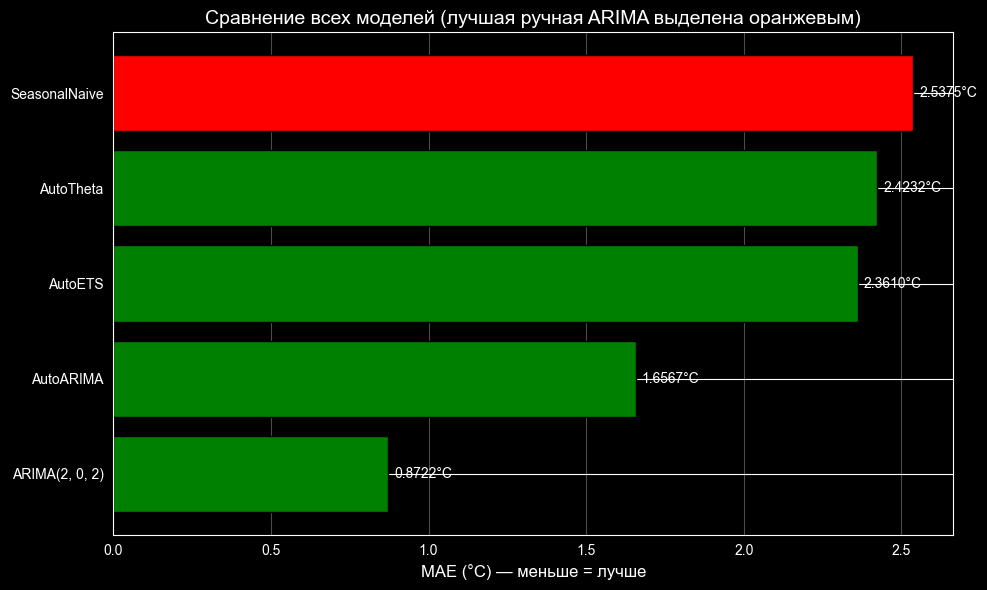


 Лучшая модель: ARIMA(2, 0, 2) с MAE = 0.8722°C


In [25]:
# Сравниваем лучшую ручную ARIMA с AutoARIMA
fig, ax = plt.subplots(figsize=(10, 6))

models_names = ['AutoARIMA', f'ARIMA{best_params}', 'AutoETS', 'AutoTheta', 'SeasonalNaive']
mae_values = [mae_auto, best_mae]

# Добавляем остальные модели из results_data
for r in results_data:
    if r['model'] not in ['AutoARIMA', 'SeasonalNaive']:
        models_names.append(r['model'])
        mae_values.append(r['MAE'])

# Добавляем бейзлайн
models_names.append('SeasonalNaive')
mae_values.append(baseline_mae)

# Сортируем по MAE
sorted_data = sorted(zip(mae_values, models_names))
mae_values_sorted = [x[0] for x in sorted_data]
models_names_sorted = [x[1] for x in sorted_data]

colors = ['green' if 'Auto' in m or 'ARIMA' in m else 'orange' if 'ARIMA' in m else 'red' for m in models_names_sorted]
bars = ax.barh(models_names_sorted, mae_values_sorted, color=colors, edgecolor='black')

ax.set_xlabel('MAE (°C) — меньше = лучше', fontsize=12)
ax.set_title('Сравнение всех моделей (лучшая ручная ARIMA выделена оранжевым)', fontsize=14)
ax.grid(True, alpha=0.3, axis='x')

for bar, mae in zip(bars, mae_values_sorted):
    ax.text(mae + 0.02, bar.get_y() + bar.get_height()/2,
            f'{mae:.4f}°C', va='center', fontsize=10)

plt.tight_layout()

plt.show()

print(f"\n Лучшая модель: {models_names_sorted[0]} с MAE = {mae_values_sorted[0]:.4f}°C")

**Итог: Для сравнения было взято 4 модели с автоматческим подбором параметров, 1 модель с ручным автоподбором и 1 бейзлайн, лучше всего с предсказанием на неделю справилась модель ARIMA со средней ошибкой 0,87 °C**